Models loaded:
  - Seq2Seq + Bahdanau Attention
  - Seq2Seq without Attention


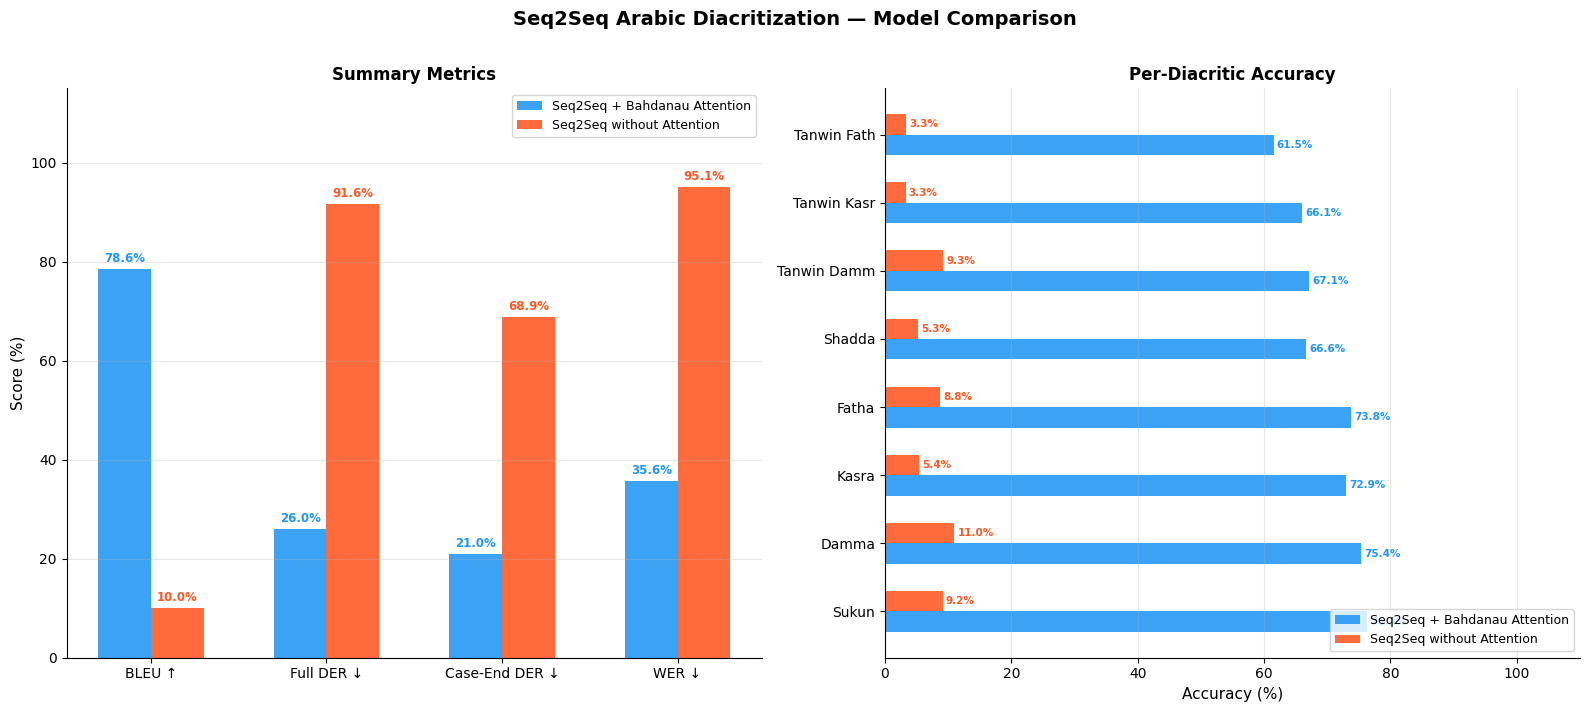

Saved → /content/model_comparison.png

IMPROVEMENT SUMMARY (No Attention → With Attention)
  BLEU           :   9.95%  →   78.60%   (+68.65pp) ↑
  Full DER       :  91.64%  →   26.02%   (-65.62pp) ↓
  Case-End DER   :  68.86%  →   20.99%   (-47.87pp) ↓
  WER            :  95.06%  →   35.64%   (-59.42pp) ↓

  Per-Diacritic Accuracy Gains:
  Diacritic        No Attn     Attn     Gain
  ------------------------------------------
  Sukun              9.17%    76.34%  + 67.18pp
  Damma             11.01%    75.42%  + 64.41pp
  Kasra              5.42%    72.93%  + 67.51pp
  Fatha              8.78%    73.79%  + 65.01pp
  Shadda             5.27%    66.65%  + 61.37pp
  Tanwin Damm        9.26%    67.12%  + 57.86pp
  Tanwin Kasr        3.27%    66.09%  + 62.81pp
  Tanwin Fath        3.33%    61.53%  + 58.19pp


In [1]:
# ============================================================
# RESULTS: LOAD & COMPARE TWO MODELS
# ============================================================

import json
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────
# 1. LOAD RESULTS
# ─────────────────────────────────────────
with open("/content/results.json", 'r', encoding='utf-8') as f:
    results = json.load(f)

model_names = list(results.keys())
print("Models loaded:")
for name in model_names:
    print(f"  - {name}")

# ─────────────────────────────────────────
# 2. PLOT
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Seq2Seq Arabic Diacritization — Model Comparison",
             fontsize=14, fontweight='bold', y=1.01)

colors = ['#2196F3', '#FF5722']   # blue = attention, orange = no attention

# ── Plot 1: Summary Metrics ──────────────
ax1 = axes[0]

summary_metrics = {
    "BLEU ↑"          : "bleu",
    "Full DER ↓"      : "full_der",
    "Case-End DER ↓"  : "case_ending_der",
    "WER ↓"           : "wer",
}

x      = np.arange(len(summary_metrics))
width  = 0.30
labels = list(summary_metrics.keys())
keys   = list(summary_metrics.values())

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = [results[model_name][k] * 100 for k in keys]
    offset = (i - 0.5) * width
    bars   = ax1.bar(x + offset, values, width,
                     label=model_name, color=color, alpha=0.88)

    for bar, val in zip(bars, values):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=color
        )

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel("Score (%)", fontsize=11)
ax1.set_ylim(0, 115)
ax1.set_title("Summary Metrics", fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# ── Plot 2: Per-Diacritic Accuracy ───────
ax2 = axes[1]

# Diacritics sorted by attention model accuracy (descending)
diac_names = [
    "Sukun", "Damma", "Kasra", "Fatha",
    "Shadda", "Tanwin Damm", "Tanwin Kasr", "Tanwin Fath"
]

y      = np.arange(len(diac_names))
height = 0.30

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    per_diac = results[model_name]["Per-Diacritic results"]
    values   = [per_diac[d]["accuracy"] * 100 for d in diac_names]
    offset   = (i - 0.5) * height
    bars     = ax2.barh(y + offset, values, height,
                        label=model_name, color=color, alpha=0.88)

    for bar, val in zip(bars, values):
        ax2.text(
            val + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            ha='left', va='center',
            fontsize=7.5, fontweight='bold', color=color
        )

ax2.set_yticks(y)
ax2.set_yticklabels(diac_names, fontsize=10)
ax2.set_xlabel("Accuracy (%)", fontsize=11)
ax2.set_xlim(0, 110)
ax2.set_title("Per-Diacritic Accuracy", fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("/content/model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/model_comparison.png")

# ─────────────────────────────────────────
# 3. PRINT IMPROVEMENT SUMMARY
# ─────────────────────────────────────────
print("\n" + "="*55)
print("IMPROVEMENT SUMMARY (No Attention → With Attention)")
print("="*55)

m1 = results["Seq2Seq without Attention"]
m2 = results["Seq2Seq + Bahdanau Attention"]

summary = {
    "BLEU"          : ("bleu",           "↑", True),
    "Full DER"      : ("full_der",       "↓", False),
    "Case-End DER"  : ("case_ending_der","↓", False),
    "WER"           : ("wer",            "↓", False),
}

for label, (key, arrow, higher_better) in summary.items():
    v1   = m1[key] * 100
    v2   = m2[key] * 100
    diff = v2 - v1
    sign = "+" if diff > 0 else ""
    print(f"  {label:<15}: "
          f"{v1:>6.2f}%  →  {v2:>6.2f}%   "
          f"({sign}{diff:.2f}pp) {arrow}")

print("\n  Per-Diacritic Accuracy Gains:")
print(f"  {'Diacritic':<15} {'No Attn':>8} {'Attn':>8} {'Gain':>8}")
print("  " + "-"*42)

per1 = m1["Per-Diacritic results"]
per2 = m2["Per-Diacritic results"]

for d in diac_names:
    v1   = per1[d]["accuracy"] * 100
    v2   = per2[d]["accuracy"] * 100
    gain = v2 - v1
    print(f"  {d:<15} {v1:>7.2f}%  {v2:>7.2f}%  "
          f"+{gain:>6.2f}pp")